In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score



# LOADING DATASET

In [3]:
train = pd.read_csv("train.csv")
stores = pd.read_csv("stores.csv")
features = pd.read_csv("features.csv")

In [4]:
train.head(2)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True


In [5]:
stores.head(2)

,Store,Type,Size
0,1,A,151315
1,2,A,202307


In [6]:
features.head(2)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True


# MERGING THE DATASET

In [8]:
df = pd.merge(train, features, on=["Store", "Date"], how="left")


In [9]:
df.head(2)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True


In [10]:
df.shape

(421570, 15)

In [11]:
df = pd.merge(df, stores, on="Store", how="left")


In [12]:
df.head(2)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315


In [13]:
df.shape

(421570, 17)

In [14]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
dtype: int64

In [15]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day

# CONVERT BOOLEAN HOLIDAY TO INTEGER

In [17]:
df["IsHoliday_y"] = df["IsHoliday_y"].astype(int)


# SORT DATE BY DATE

In [19]:
df=df.sort_values("Date")

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 421570 entries, 0 to 421569
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  IsHoliday_y   421570 non-null  int32         
 15  Type          421570 n

In [21]:
df.head(2)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,...,NaN,211.096358,8.106,0,A,151315,2010,2,5,5
277665,29,5,2010-02-05,15552.08,False,24.36,2.788,NaN,NaN,NaN,...,NaN,131.527903,10.064,0,B,93638,2010,2,5,5


In [22]:
df=df.drop(columns=['IsHoliday_x'])

In [23]:
df=df.rename(columns={'IsHoliday_y':'IsHoliday'})

# HANDLING MISSING VALUES

In [25]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
df[markdown_cols] = df[markdown_cols].fillna(0)

In [26]:
print(df[markdown_cols].isnull().sum())

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64


# Checking Dupicates

In [28]:
duplicates = df[df.duplicated(keep=False)]
print(duplicates)


Empty DataFrame
Columns: [Store, Dept, Date, Weekly_Sales, Temperature, Fuel_Price, MarkDown1, MarkDown2, MarkDown3, MarkDown4, MarkDown5, CPI, Unemployment, IsHoliday, Type, Size, Year, Month, Week, Day]
Index: []


In [29]:
df.head()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0,A,151315,2010,2,5,5
277665,29,5,2010-02-05,15552.08,24.36,2.788,0.0,0.0,0.0,0.0,0.0,131.527903,10.064,0,B,93638,2010,2,5,5
277808,29,6,2010-02-05,3200.22,24.36,2.788,0.0,0.0,0.0,0.0,0.0,131.527903,10.064,0,B,93638,2010,2,5,5
277951,29,7,2010-02-05,10820.05,24.36,2.788,0.0,0.0,0.0,0.0,0.0,131.527903,10.064,0,B,93638,2010,2,5,5
278094,29,8,2010-02-05,20055.64,24.36,2.788,0.0,0.0,0.0,0.0,0.0,131.527903,10.064,0,B,93638,2010,2,5,5


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 421570 entries, 0 to 421569
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   Temperature   421570 non-null  float64       
 5   Fuel_Price    421570 non-null  float64       
 6   MarkDown1     421570 non-null  float64       
 7   MarkDown2     421570 non-null  float64       
 8   MarkDown3     421570 non-null  float64       
 9   MarkDown4     421570 non-null  float64       
 10  MarkDown5     421570 non-null  float64       
 11  CPI           421570 non-null  float64       
 12  Unemployment  421570 non-null  float64       
 13  IsHoliday     421570 non-null  int32         
 14  Type          421570 non-null  object        
 15  Size          421570 n

## Aggregation of weekly_sales on store

In [32]:
df = df.groupby(['Store', 'Date'], as_index=False).agg({
    'Weekly_Sales': 'sum',
    'IsHoliday': 'first',
    'Temperature': 'mean',
    'Fuel_Price': 'sum',
    'MarkDown1': 'mean',
    'MarkDown2': 'mean',
    'MarkDown3': 'mean',
    'MarkDown4': 'mean',
    'MarkDown5': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'Type': 'first',
    'Size': 'first',
    'Year': 'first',
    'Month': 'first',
    'Week': 'first',
    'Day': 'first'
})

In [33]:
df.tail(10)

,Store,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Day
6425,45,2012-08-24,718232.26,0,72.62,256.878,7936.20,58.38,22.00,5518.07,2291.97,191.344887,8.684,B,118221,2012,8,34,24
6426,45,2012-08-31,734297.87,0,75.09,262.956,23641.30,6.00,92.93,6988.31,3992.13,191.461281,8.684,B,118221,2012,8,35,31
6427,45,2012-09-07,766512.66,1,75.70,269.859,11024.45,12.80,52.63,1854.77,2055.70,191.577676,8.684,B,118221,2012,9,36,7
6428,45,2012-09-14,702238.27,0,67.87,272.412,11407.95,0.00,4.30,3421.72,5268.92,191.699850,8.684,B,118221,2012,9,37,14
6429,45,2012-09-21,723086.20,0,65.32,270.546,8452.20,92.28,63.24,2376.38,8670.40,191.856704,8.684,B,118221,2012,9,38,21
6430,45,2012-09-28,713173.95,0,64.88,263.802,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221,2012,9,39,28
6431,45,2012-10-05,733455.07,0,64.89,270.980,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,B,118221,2012,10,40,5
6432,45,2012-10-12,734464.36,0,54.47,264.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,B,118221,2012,10,41,12
6433,45,2012-10-19,718125.53,0,56.47,261.954,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,B,118221,2012,10,42,19
6434,45,2012-10-26,760281.43,0,58.85,260.094,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,B,118221,2012,10,43,26


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   IsHoliday     6435 non-null   int32         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   MarkDown1     6435 non-null   float64       
 7   MarkDown2     6435 non-null   float64       
 8   MarkDown3     6435 non-null   float64       
 9   MarkDown4     6435 non-null   float64       
 10  MarkDown5     6435 non-null   float64       
 11  CPI           6435 non-null   float64       
 12  Unemployment  6435 non-null   float64       
 13  Type          6435 non-null   object        
 14  Size          6435 non-null   int64         
 15  Year          6435 non-null   int32   

In [35]:
from sklearn.model_selection import train_test_split
features = ['Store' ,'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','Size']  # choose based on EDA
X = df[features]
y = df['Weekly_Sales'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



## Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_scaled = scaler.fit_transform(X_train)
test_scaled=scaler.transform(X_test)

In [38]:
train_scaled

array([[-1.16466588,  0.8057783 , -1.01141264, ..., -0.27920937,
        -0.37673948,  0.39298496],
       [-1.24165623, -2.15108453,  0.37061797, ..., -0.27920937,
        -0.37673948, -0.94354094],
       [ 1.45300579,  0.04355515, -1.75273613, ..., -0.27920937,
        -0.37673948, -1.43501303],
       ...,
       [ 1.06805407,  1.42237786, -0.77918794, ..., -0.27920937,
        -0.37673948, -1.43152775],
       [ 1.14504441, -0.85508863, -0.92722343, ..., -0.27197855,
        -0.19428249, -1.43501303],
       [-1.24165623, -1.79487513, -0.94236125, ..., -0.27920937,
        -0.37673948, -0.94354094]])

In [39]:
x_train=pd.DataFrame(train_scaled, columns=X_train.columns)
x_test=pd.DataFrame(test_scaled, columns=X_test.columns)

In [40]:
x_train

,Store,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Size
0,-1.164666,0.805778,-1.011413,1.103804,-0.897874,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,0.392985
1,-1.241656,-2.151085,0.370618,0.522548,0.438475,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,-0.943541
2,1.453006,0.043555,-1.752736,-1.146134,0.537246,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,-1.435013
3,-0.625733,0.473930,1.263129,-0.899892,-0.101831,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,-0.103525
4,1.453006,1.459731,-0.975454,-1.077504,0.138957,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,-1.435013
...,...,...,...,...,...,...,...,...,...,...,...,...
5143,0.298151,-1.143088,0.532502,-0.873464,-0.090619,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,1.170931
5144,1.068054,-0.324564,-2.161648,0.989125,0.255881,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,-1.431528
5145,1.068054,1.422378,-0.779188,1.088999,0.096246,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,-1.431528
5146,1.145044,-0.855089,-0.927223,-1.056351,2.612512,3.725401,-0.364883,0.213342,-0.080467,-0.271979,-0.194282,-1.435013


In [41]:
x_test

,Store,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Size
0,-0.394762,-0.976893,-0.577048,-1.012720,0.643492,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,-0.152382
1,0.067180,0.457148,1.454715,-0.924048,0.114932,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,1.165149
2,-1.626608,0.294201,0.531642,1.166123,-0.296704,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,1.141195
3,0.221160,-1.101945,0.531069,-0.893570,-0.212882,-0.268427,0.850822,1.190543,-0.025583,0.174565,0.191518,0.352350
4,0.991064,-0.047392,-2.685598,0.979040,0.297525,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,-1.431528
...,...,...,...,...,...,...,...,...,...,...,...,...
1282,-0.317772,0.745147,-0.348070,-0.991574,0.054601,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,1.165149
1283,1.683977,0.478261,-0.558376,0.267528,0.481721,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,-0.190910
1284,1.683977,-1.793251,-0.811565,0.263065,0.531373,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,-0.190910
1285,-1.626608,0.153450,-0.590944,0.991765,0.108525,-0.268427,-0.427811,-0.166104,-0.080467,-0.279209,-0.376739,1.141195


## Linear Regression

In [129]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print("R-squared:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

R-squared: 0.6976135094412986
RMSE: 312114.06283130037
                Coefficient
Store         -96324.323769
Temperature    23523.712628
Fuel_Price    -37396.530311
CPI           -73751.729867
Unemployment  -24004.284835
IsHoliday      11035.436169
MarkDown1       6681.679614
MarkDown2       1296.458632
MarkDown3      47020.887115
MarkDown4       3205.089937
MarkDown5      26201.226693
Size          444499.537797


In [131]:
y_train_pred = model.predict(X_train)

In [133]:
r2_train = r2_score(y_train, y_train_pred)
print("R² Score on Training Data:", r2_train)
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))


R² Score on Training Data: -13068451015.05079
RMSE: 64416288508.07608


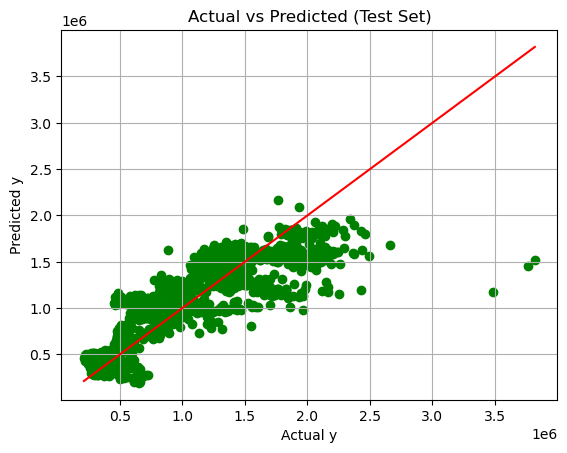

In [139]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

plt.scatter(y_test, y_test_pred, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red') 
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Actual vs Predicted (Test Set)")
plt.grid(True)
plt.show()

## Decision Tree Regressor

In [155]:
from sklearn.tree import DecisionTreeRegressor

In [157]:
model = DecisionTreeRegressor(splitter='best',max_depth=None,min_samples_split=5)
model.fit(x_train, y_train)


DecisionTreeRegressor(min_samples_split=5)

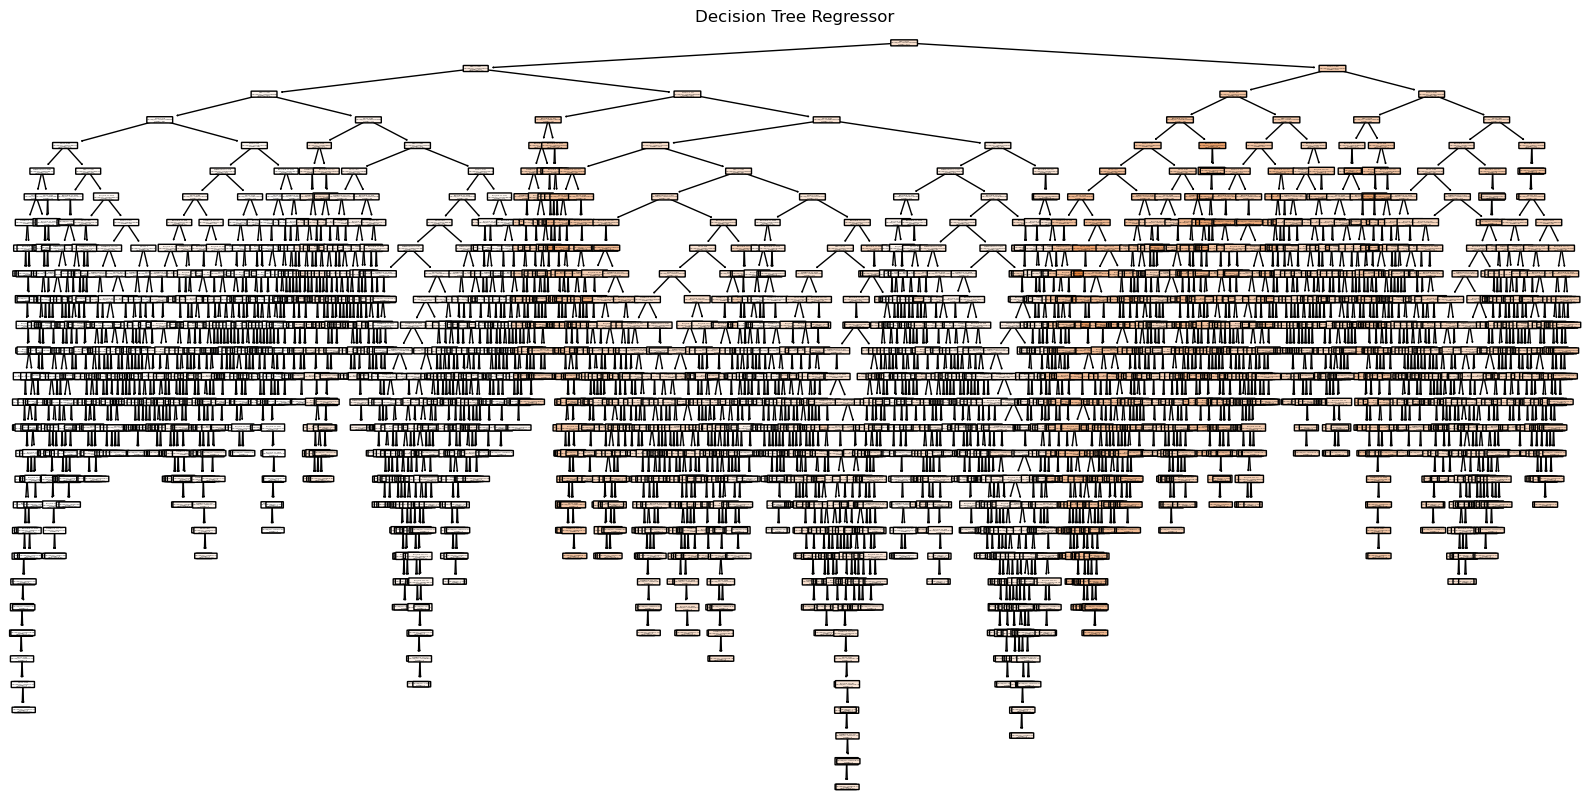

In [159]:
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, filled=True, rounded=True)
plt.title("Decision Tree Regressor")
plt.show()

In [160]:
y_pred =model.predict(x_test)


In [161]:
print("R-squared:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R-squared: 0.9012888228595902
RMSE: 178326.2636185484


In [162]:
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
print("R² Score on Training Data:", r2_train)
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))


R² Score on Training Data: -1.0886880506303274
RMSE: 814367.4978156895


In [88]:
importances = pd.DataFrame(model.feature_importances_, index=X.columns, columns=["Importance"])
print(importances.sort_values("Importance", ascending=False))

              Importance
Size            0.701535
Store           0.158108
CPI             0.070928
MarkDown3       0.019951
Unemployment    0.016185
Temperature     0.012543
Fuel_Price      0.012283
MarkDown1       0.003673
MarkDown4       0.002072
IsHoliday       0.001167
MarkDown5       0.000984
MarkDown2       0.000573


## RandomForestRegressor

In [163]:
from sklearn.ensemble import RandomForestRegressor

In [164]:
model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [165]:
y_pred = model.predict(x_test)

In [166]:
print("R-squared_RFR:", r2_score(y_test, y_pred))
print("RMSE_RFR:", np.sqrt(mean_squared_error(y_test, y_pred)))


R-squared_RFR: 0.9376952201055473
RMSE_RFR: 141674.87159513505


In [167]:
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
print("R² Score on Training Data:", r2_train)
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))


R² Score on Training Data: -1.1133074534333423
RMSE: 819152.9196759438


In [99]:
importances = pd.DataFrame(model.feature_importances_, index=X.columns, columns=["Importance"])
print(importances.sort_values("Importance", ascending=False))

              Importance
Size            0.701054
Store           0.146830
CPI             0.073432
MarkDown3       0.020697
Unemployment    0.020208
Temperature     0.015420
Fuel_Price      0.012472
MarkDown4       0.002675
MarkDown1       0.002139
MarkDown5       0.001982
IsHoliday       0.001896
MarkDown2       0.001196


In [113]:
class MeraLR:
    
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,x_train,y_train):
        x_train = np.insert(x_train,0,1,axis=1)
        
        # calcuate the coeffs
        betas = np.linalg.inv(np.dot(x_train.T,x_train)).dot(x_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]
    
    def predict(self,x_test):
        y_pred = np.dot(x_test,self.coef_) + self.intercept_
        return y_pred
        

In [115]:
lr = MeraLR()

In [117]:
lr.fit(x_train,y_train)

In [ ]:
y_pred = lr.predict(x_test)

In [119]:
r2_score(y_test,y_pred)

0.6976135094412986

In [121]:
rmse=np.sqrt(mean_squared_error(y_test, y_pred))

In [123]:
rmse

312114.06283130037

In [125]:
lr.coef_

array([-96324.32376852,  23523.7126284 , -37396.53031147, -73751.72986699,
       -24004.28483474,  11035.43616901,   6681.67961429,   1296.45863192,
        47020.88711495,   3205.08993698,  26201.22669341, 444499.53779707])

In [127]:
lr.intercept_

1044996.4142812742